In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dati
data = np.load('online_learning_data.npy')
X_train = data['X_train'] # (16000, 2)
y_train = data['y_train'] # (16000,)
X_test = data['X_test']   # (4000, 2)
y_test = data['y_test']   # (4000,)

# 1. CONVERSIONE DELLE STRINGHE IN NUMERI
# Se la stringa è 'working', diventa 1. Altrimenti (se è 'not working'), diventa -1.
y_train = np.where(y_train == 'working', 1, -1)
y_test = np.where(y_test == 'working', 1, -1)


# Suddivisione pre e post shift (i = 8000)
X_pre = X_train[:8000]
y_pre = y_train[:8000]
X_post = X_train[8000:]
y_post = y_train[8000:]

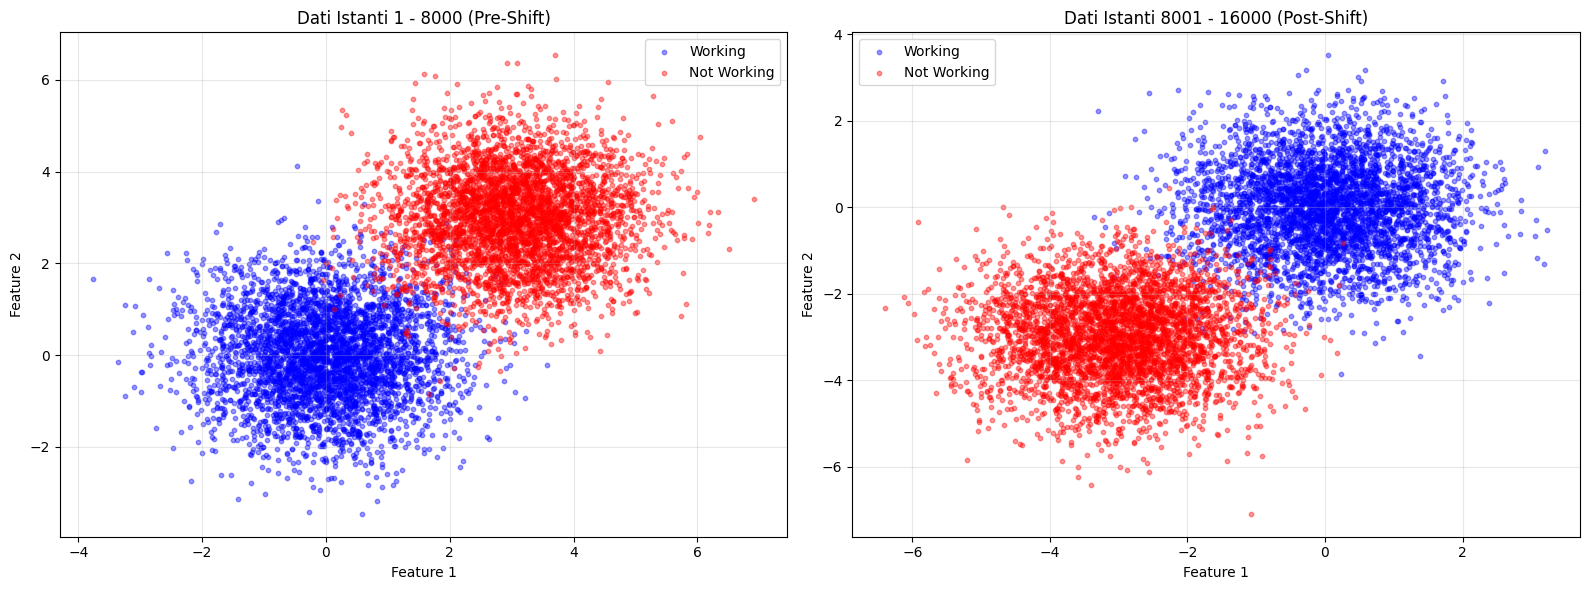

In [52]:
# 2. Creazione dei Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Primo blocco: i = 1 a 8000
ax1.scatter(X_pre[y_pre == 1, 0], X_pre[y_pre == 1, 1], 
            color='blue', label='Working', alpha=0.4, s=10)
ax1.scatter(X_pre[y_pre == -1, 0], X_pre[y_pre == -1, 1], 
            color='red', label='Not Working', alpha=0.4, s=10)
ax1.set_title('Dati Istanti 1 - 8000 (Pre-Shift)')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Secondo blocco: i = 8001 a 16000
ax2.scatter(X_post[y_post == 1, 0], X_post[y_post == 1, 1], 
            color='blue', label='Working', alpha=0.4, s=10)
ax2.scatter(X_post[y_post == -1, 0], X_post[y_post == -1, 1], 
            color='red', label='Not Working', alpha=0.4, s=10)
ax2.set_title('Dati Istanti 8001 - 16000 (Post-Shift)')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1. Inversione delle Classi (Concept Drift)
La modifica più evidente non riguarda solo la posizione dei punti, ma il significato delle feature rispetto alla variabile target:

Pre-Shift (Sinistra): La classe "Working" (blu) è concentrata in basso a sinistra, mentre la classe "Not Working" (rossa) si trova in alto a destra.

Post-Shift (Destra): Le posizioni si invertono quasi specularmente. Ora la classe "Working" (blu) occupa la porzione in alto a destra, mentre la classe "Not Working" (rossa) si sposta in basso a sinistra.

2. Spostamento delle Feature (Feature Drift)
Oltre all'inversione delle etichette, cambiano i valori numerici delle coordinate:

I centri delle distribuzioni (le medie) subiscono una traslazione netta lungo entrambi gli assi (Feature 1 e Feature 2).

Un classificatore statico addestrato sulla prima parte fallirebbe completamente sulla seconda, poiché predirebbe l'esatto opposto della realtà.

3. Separabilità Lineare
In entrambi i periodi, le classi rimangono linearmente separabili (è possibile tracciare una retta per dividerle con pochi errori).

Tuttavia, il confine di decisione (decision boundary) deve ruotare o traslare drasticamente per adattarsi al nuovo regime dopo l'istante 8000.

In [53]:
import numpy as np

# Caricamento dati (assicurati che il file sia nella stessa cartella)


# Definizione dei chunk
def calculate_priors(y_chunk, chunk_name):
    # Identifica le classi (es. 'working' e 'not working')
    classes = np.unique(y_chunk)
    n_total = len(y_chunk)
    
    print(f"--- Prior per {chunk_name} ---")
    priors = {}
    for c in classes:
        # Conta quanti campioni appartengono alla classe c
        n_c = np.sum(y_chunk == c)
        prior_c = n_c / n_total
        priors[c] = prior_c
        print(f"Classe '{c}': {prior_c:.4f} ({n_c}/{n_total} campioni)")
    print()
    return priors

# Calcolo effettivo
priors_1 = calculate_priors(y_pre, "Chunk 1 (i <= 8000)")
priors_2 = calculate_priors(y_post, "Chunk 2 (i > 8000)")

--- Prior per Chunk 1 (i <= 8000) ---
Classe '-1': 0.4994 (3995/8000 campioni)
Classe '1': 0.5006 (4005/8000 campioni)

--- Prior per Chunk 2 (i > 8000) ---
Classe '-1': 0.5034 (4027/8000 campioni)
Classe '1': 0.4966 (3973/8000 campioni)



In [54]:
import numpy as np

# Calcolo della matrice di correlazione (che è la covarianza normalizzata)
corr_matrix = np.corrcoef(X_train[:, 0], X_train[:, 1])
r = corr_matrix[0, 1]

print(f"Il coefficiente di correlazione è: {r:.4f}")

if abs(r) < 0.1:
    print("Le feature sono quasi incorrelate.")
else:
    print("Esiste una correlazione significativa.")

Il coefficiente di correlazione è: 0.8164
Esiste una correlazione significativa.


In [55]:
import numpy as np

# 1. DEFINIZIONE DELLE MATRICI DI COVARIANZA E MEDIE
def train_model(X, y):
    params = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        # Calcoliamo la Media (mu) e la Covarianza (Sigma)
        mu = np.mean(X_cls, axis=0)
        sigma = np.cov(X_cls, rowvar=False) 
        
        params[cls] = {
            'mu': mu,
            'sigma_inv': np.linalg.inv(sigma),     # Inversa per la formula
            'log_det': np.log(np.linalg.det(sigma)) # ln|Sigma| per la formula
        }
    return params

# 2. DEFINIZIONE DELLA REGOLA DI DECISIONE (g_k)
def g_k(x, p):
    diff = x - p['mu']
    prod = diff.T @ p['sigma_inv'] @ diff
    
    # Formula finale g_k(x)
    return -0.5 * prod - 0.5 * p['log_det']

# 3. APPLICAZIONE SUI TUOI CHUNK
# Impariamo i parametri dai due chunk di training
modello_pre  = train_model(X_pre, y_pre)
modello_post = train_model(X_post, y_post)

def classifica_tutto(X_chunk, parametri_modello):
    previsioni = []
    # Otteniamo le chiavi delle classi (es: 1 e -1) dal modello
    classi = (parametri_modello.keys())
    
    for x in X_chunk:
        # Calcoliamo il punteggio g_k per ogni classe disponibile
        punteggi = {c: g_k(x, parametri_modello[c]) for c in classi}
        
        # Regola MAP: scegliamo la classe con il punteggio massimo
        scelta = max(punteggi, key=punteggi.get)
        previsioni.append(scelta)
        
    return np.array(previsioni)

# 1. Applichiamo la classificazione a tutti i chunk del Test Set
# Usiamo i parametri del Chunk 1 per la prima parte e del Chunk 2 per la seconda
y_pred_pre = classifica_tutto(X_test[:2000], modello_pre)
y_pred_post = classifica_tutto(X_test[2000:], modello_post)


print(f"\n--- VALORI NUMERICI DELLE MATRICI (Punto B) ---")
for cls in modello_pre:
    print(f"\nClasse {cls} (Pre-Shift):")
    print(f"Media mu:\n{modello_pre[cls]['mu']}")
    # Recuperiamo Sigma invertendo l'inversa già calcolata o ricalcolandola
    sigma = np.linalg.inv(modello_pre[cls]['sigma_inv'])
    print(f"Matrice Sigma:\n{sigma}")
accuracy_MAP_pre = np.mean(y_pred_pre.flatten() == y_test[:2000].flatten())
accuracy_MAP_post = np.mean(y_pred_post.flatten() == y_test[2000:].flatten())
print(f"Accuratezza Classificatore MAP Pre-Shift: {accuracy_MAP_pre:.2%}")
print(f"Accuratezza Classificatore MAP Post-Shift: {accuracy_MAP_post:.2%}")



--- VALORI NUMERICI DELLE MATRICI (Punto B) ---

Classe -1 (Pre-Shift):
Media mu:
[3.03952802 2.99236995]
Matrice Sigma:
[[1.01687677 0.01308446]
 [0.01308446 1.01631047]]

Classe 1 (Pre-Shift):
Media mu:
[-0.00416107 -0.00112413]
Matrice Sigma:
[[ 1.01348366 -0.00462749]
 [-0.00462749  1.05824698]]
Accuratezza Classificatore MAP Pre-Shift: 98.15%
Accuratezza Classificatore MAP Post-Shift: 98.40%


In [56]:
X_test.shape

(4000, 2)

Per ogni modello, l'errore si calcola così:$$\text{Error Probability} = \frac{\text{Numero di previsioni sbagliate}}{\text{Totale osservazioni}}$$

In [57]:
# --- LOGICA PER IL CONFRONTO ---

def calcola_errore(previsioni, reali):
    return np.mean(previsioni != reali)

# 1. ERRORI MAP (Usando la regola g_k che abbiamo scritto prima)
pred_map_pre = classifica_tutto(X_test[:2000], modello_pre)
pred_map_post = classifica_tutto(X_test[2000:], modello_post)

err_map_pre = calcola_errore(pred_map_pre, y_test[:2000])
err_map_post = calcola_errore(pred_map_post, y_test[2000:])

# 2. ERRORI LOGISTICI (Supponendo che tu abbia i modelli log_pre e log_post)
# pred_log_pre = log_pre.predict(X_test[:2000])
# pred_log_post = log_post.predict(X_test[2000:])
# err_log_pre = calcola_errore(pred_log_pre, y_test[:2000])
# err_log_post = calcola_errore(pred_log_post, y_test[2000:])

# 3. CONFRONTO FINALE
print("--- TEST ERROR PROBABILITIES ---")
print(f"MAP - Chunk 1: {err_map_pre:.4f} | Chunk 2: {err_map_post:.4f}")
# print(f"LOG - Chunk 1: {err_log_pre:.4f} | Chunk 2: {err_log_post:.4f}")

--- TEST ERROR PROBABILITIES ---
MAP - Chunk 1: 0.0185 | Chunk 2: 0.0160
